In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Baseline transforms (no augmentation yet)
transform = transforms.Compose([
    transforms.Resize((128, 128)), 
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(root='dataset/train', transform=transform)
test_dataset = datasets.ImageFolder(root='dataset/test', transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Classes: {train_dataset.classes}") # Expected: 5 classes

Classes: ['Bridge', 'Crosswalk', 'Elevator', 'Escalator', 'Stair']


In [9]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Input shape: (Batch, 3, 128, 128)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Shape after pool: (Batch, 16, 64, 64)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        
        # Shape after pool: (Batch, 32, 32, 32)
        self.fc1 = nn.Linear(32 * 32 * 32, 128)
        
        # 5 output neurons mapped to the 5 classes
        self.fc2 = nn.Linear(128, 5) # <- change!!!
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x) 
        return x

model = BaselineCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### Step A

In [10]:
# Tracking variables
train_losses = []
train_accuracies = []
test_accuracies = []
epochs = 12

for epoch in range(epochs):
    # --- Training Phase ---
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for images, labels in train_loader:
        optimizer.zero_grad() # Clear gradients
        
        outputs = model(images) # Forward pass
        loss = criterion(outputs, labels) # Calculate loss
        
        loss.backward() # Backward pass
        optimizer.step() # Update weights
        
        # Track training metrics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    epoch_loss = running_loss / len(train_loader)
    epoch_train_acc = 100 * correct_train / total_train
    
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_train_acc)
    
    # --- Evaluation Phase ---
    model.eval()
    correct_test = 0
    total_test = 0
    
    with torch.no_grad(): # Disable gradient calculation for inference
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()
            
    epoch_test_acc = 100 * correct_test / total_test
    test_accuracies.append(epoch_test_acc)
    
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Train Acc: {epoch_train_acc:.2f}%, Test Acc: {epoch_test_acc:.2f}%")

Epoch [1/12], Loss: 1.7529, Train Acc: 22.00%, Test Acc: 29.41%
Epoch [2/12], Loss: 1.5900, Train Acc: 30.00%, Test Acc: 17.65%
Epoch [3/12], Loss: 1.4225, Train Acc: 52.00%, Test Acc: 35.29%
Epoch [4/12], Loss: 1.1852, Train Acc: 70.00%, Test Acc: 47.06%
Epoch [5/12], Loss: 0.9740, Train Acc: 82.00%, Test Acc: 52.94%
Epoch [6/12], Loss: 0.7343, Train Acc: 88.00%, Test Acc: 52.94%
Epoch [7/12], Loss: 0.5069, Train Acc: 92.00%, Test Acc: 52.94%
Epoch [8/12], Loss: 0.4235, Train Acc: 94.00%, Test Acc: 58.82%
Epoch [9/12], Loss: 0.2933, Train Acc: 96.00%, Test Acc: 52.94%
Epoch [10/12], Loss: 0.1853, Train Acc: 96.00%, Test Acc: 52.94%
Epoch [11/12], Loss: 0.1216, Train Acc: 98.00%, Test Acc: 58.82%
Epoch [12/12], Loss: 0.0874, Train Acc: 100.00%, Test Acc: 64.71%


### Step B

In [11]:
# 1. Improved Training Transforms (with Augmentation)
train_transform_augmented = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),      # Randomly flip horizontally
    transforms.RandomRotation(degrees=15),       # Randomly rotate between -15 and 15 degrees
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Slight lighting variations
    transforms.ToTensor()
])

# 2. Test Transforms (Strictly standard preprocessing)
test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

# 3. Re-initialize Datasets and Loaders
train_dataset_aug = datasets.ImageFolder(root='dataset/train', transform=train_transform_augmented)
test_dataset = datasets.ImageFolder(root='dataset/test', transform=test_transform)

train_loader_aug = DataLoader(train_dataset_aug, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 4. Re-initialize the Model and Optimizer to start fresh
improved_model = BaselineCNN()
criterion = nn.CrossEntropyLoss()
improved_optimizer = optim.Adam(improved_model.parameters(), lr=0.001)

In [12]:
# Tracking variables for improved model
improved_train_losses = []
improved_train_accuracies = []
improved_test_accuracies = []
epochs = 12

for epoch in range(epochs):
    # --- Training Phase ---
    improved_model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for images, labels in train_loader_aug:
        improved_optimizer.zero_grad() # Clear gradients
        
        outputs = improved_model(images) # Forward pass
        loss = criterion(outputs, labels) # Calculate loss
        
        loss.backward() # Backward pass
        improved_optimizer.step() # Update weights
        
        # Track training metrics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    epoch_loss = running_loss / len(train_loader_aug)
    epoch_train_acc = 100 * correct_train / total_train
    
    improved_train_losses.append(epoch_loss)
    improved_train_accuracies.append(epoch_train_acc)
    
    # --- Evaluation Phase ---
    improved_model.eval()
    correct_test = 0
    total_test = 0
    
    with torch.no_grad(): # Disable gradient calculation for inference
        for images, labels in test_loader:
            outputs = improved_model(images)
            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()
            
    epoch_test_acc = 100 * correct_test / total_test
    improved_test_accuracies.append(epoch_test_acc)
    
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Train Acc: {epoch_train_acc:.2f}%, Test Acc: {epoch_test_acc:.2f}%")

Epoch [1/12], Loss: 1.8778, Train Acc: 14.00%, Test Acc: 17.65%
Epoch [2/12], Loss: 1.5575, Train Acc: 42.00%, Test Acc: 29.41%
Epoch [3/12], Loss: 1.5230, Train Acc: 38.00%, Test Acc: 35.29%
Epoch [4/12], Loss: 1.4457, Train Acc: 46.00%, Test Acc: 35.29%
Epoch [5/12], Loss: 1.2992, Train Acc: 56.00%, Test Acc: 35.29%
Epoch [6/12], Loss: 1.1401, Train Acc: 56.00%, Test Acc: 41.18%
Epoch [7/12], Loss: 1.1095, Train Acc: 66.00%, Test Acc: 41.18%
Epoch [8/12], Loss: 1.0629, Train Acc: 64.00%, Test Acc: 41.18%
Epoch [9/12], Loss: 0.8646, Train Acc: 66.00%, Test Acc: 47.06%
Epoch [10/12], Loss: 0.9143, Train Acc: 64.00%, Test Acc: 41.18%
Epoch [11/12], Loss: 0.6689, Train Acc: 76.00%, Test Acc: 47.06%
Epoch [12/12], Loss: 0.7025, Train Acc: 70.00%, Test Acc: 47.06%


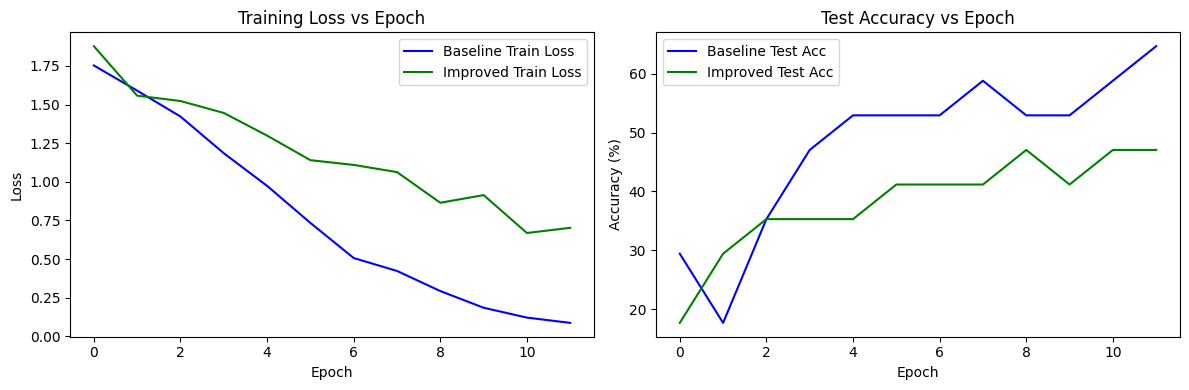

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Baseline Train Loss', color='blue')
plt.plot(improved_train_losses, label='Improved Train Loss', color='green')
plt.title('Training Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(test_accuracies, label='Baseline Test Acc', color='blue')
plt.plot(improved_test_accuracies, label='Improved Test Acc', color='green')
plt.title('Test Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

### Explanation:

Applying data augmentation artificially expands the training dataset by introducing random, realistic variations such as horizontal flips, rotations, and lighting adjustments. This prevents the convolutional neural network from memorizing exact pixel layouts or position-specific details of the original training images. By forcing the model to recognize invariant features regardless of orientation or lighting—such as the texture of stairs, the structure of a bridge, or the stripes of a crosswalk—data augmentation directly combats overfitting. Consequently, the model generalizes much better to unseen data, typically resulting in a narrower gap between training accuracy and test accuracy compared to the baseline.

### Justification for Loss Function and Output Format

For this 5-class classification task, the model outputs 5 numeric values corresponding to the five classes. We use **`nn.CrossEntropyLoss()`** as our loss function because it mathematically combines `nn.LogSoftmax()` and `nn.NLLLoss()` into a single, numerically stable operation. Consequently, it requires the model to output **raw, unnormalized logits** rather than probabilities. This is why our final layer `fc2` does not have a Softmax activation.

During evaluation, when generating the confusion matrix and predictions, we explicitly apply `F.softmax(outputs, dim=1)` to these raw logits. This converts the logits into a valid probability distribution, allowing us to accurately extract the model's confidence percentage for each predicted label.

### Step C

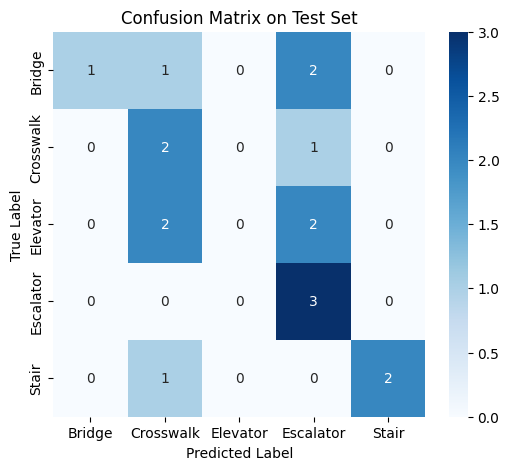

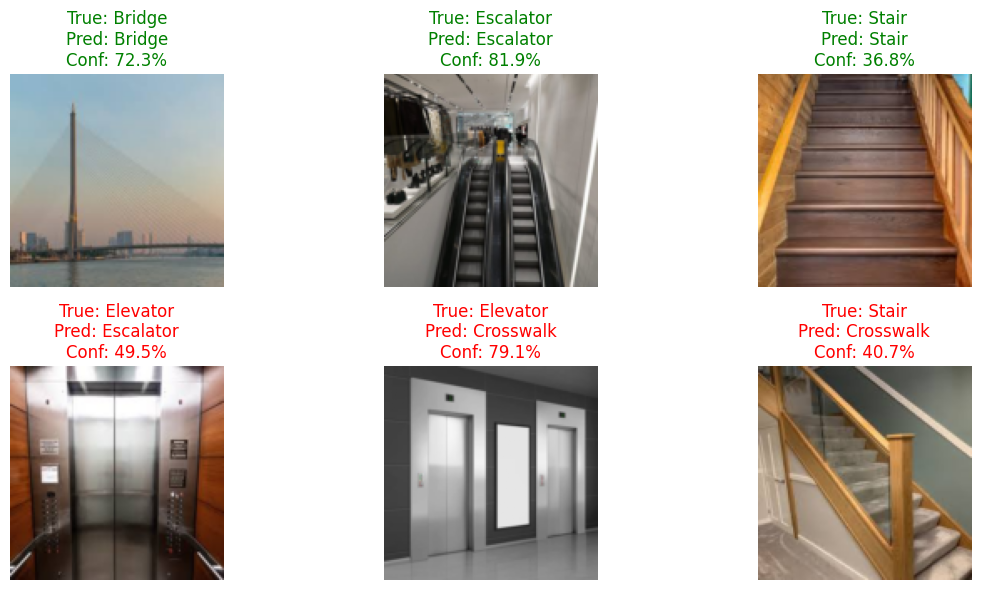

In [14]:
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# 1. Gather all predictions, labels, confidences, and images
all_preds = []
all_labels = []
all_confs = []
all_images = []

improved_model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = improved_model(images)
        
        # Convert raw logits to probabilities
        probs = F.softmax(outputs, dim=1)
        
        # Get the highest probability (confidence) and the corresponding class index
        confs, preds = torch.max(probs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_confs.extend(confs.cpu().numpy())
        all_images.extend(images.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_confs = np.array(all_confs)
all_images = np.array(all_images)

class_names = test_dataset.classes # Expected: 5 classes

# 2. Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on Test Set')
plt.show()

# 3. Extract Example Predictions (3 Correct, 3 Incorrect)
correct_idx = np.where(all_preds == all_labels)[0]
incorrect_idx = np.where(all_preds != all_labels)[0]

# Safety check: if the model performs perfectly, there may be < 3 incorrect
num_correct = min(3, len(correct_idx))
num_incorrect = min(3, len(incorrect_idx))

sampled_correct = np.random.choice(correct_idx, num_correct, replace=False) if num_correct > 0 else []
sampled_incorrect = np.random.choice(incorrect_idx, num_incorrect, replace=False) if num_incorrect > 0 else []

sampled_indices = np.concatenate([sampled_correct, sampled_incorrect])

# Plotting the examples
plt.figure(figsize=(12, 6))
for i, idx in enumerate(sampled_indices):
    plt.subplot(2, 3, i + 1)
    
    # PyTorch images are (C, H, W). Matplotlib requires (H, W, C).
    img = np.transpose(all_images[idx], (1, 2, 0))
    
    plt.imshow(img)
    plt.axis('off')
    
    true_lbl = class_names[all_labels[idx]]
    pred_lbl = class_names[all_preds[idx]]
    conf = all_confs[idx] * 100
    
    color = 'green' if true_lbl == pred_lbl else 'red'
    plt.title(f"True: {true_lbl}\nPred: {pred_lbl}\nConf: {conf:.1f}%", color=color)

plt.tight_layout()
plt.show()